# EM619 — Machine Learning
## Assignment 1 — SOLUTION KEY
**Total Marks: 20** | **Questions: 5 (4 marks each)**


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris, load_wine, load_diabetes, make_regression
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


---
## Q1. Decision Trees — Depth vs Overfitting (4 marks)
Dataset: `load_iris()`.


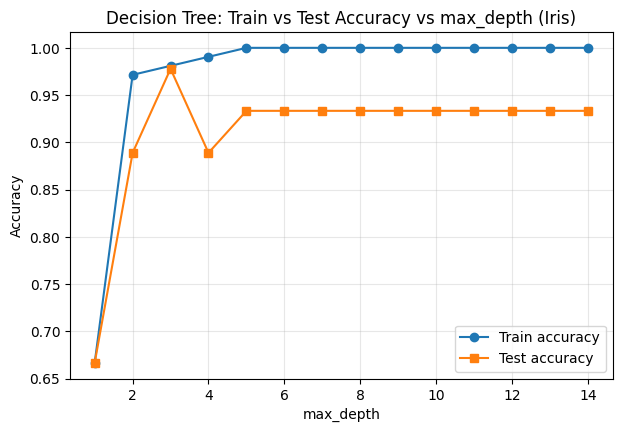

Depth with best test accuracy: 3 (test_acc=0.978)


In [2]:
def depth_vs_accuracy(X_train, y_train, X_test, y_test, depth_range):
    '''
    Train a DecisionTreeClassifier for every depth in depth_range.
    Returns train_acc, test_acc lists.
    '''
    train_acc, test_acc = [], []
    for depth in depth_range:
        clf = DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE)
        clf.fit(X_train, y_train)

        train_pred = clf.predict(X_train)
        test_pred = clf.predict(X_test)

        train_acc.append(accuracy_score(y_train, train_pred))
        test_acc.append(accuracy_score(y_test, test_pred))

    return train_acc, test_acc


# --- Data setup ---
iris = load_iris()
X, y = iris.data, iris.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)

depth_range = range(1, 15)
train_acc, test_acc = depth_vs_accuracy(X_train, y_train, X_test, y_test, depth_range)

plt.figure(figsize=(7, 4.5))
plt.plot(list(depth_range), train_acc, marker='o', label='Train accuracy')
plt.plot(list(depth_range), test_acc, marker='s', label='Test accuracy')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Decision Tree: Train vs Test Accuracy vs max_depth (Iris)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

best_depth = list(depth_range)[int(np.argmax(test_acc))]
print(f"Depth with best test accuracy: {best_depth} (test_acc={max(test_acc):.3f})")


### Observations (Q1) — reference answer
- Test accuracy peaks around `max_depth = 3–4` (Iris is near-perfectly separable at shallow depth); train accuracy reaches ~1.0 by depth 5–6 and stays there.
- **Underfitting** region: depth 1–2, where both train and test accuracy are low because the tree hasn't captured the class boundaries yet.
- **Overfitting** region: beyond ~depth 5–6, train accuracy stays pinned at 1.0 while test accuracy plateaus or slightly dips — the growing train/test gap is the overfitting signature.


---
## Q2. Bias–Variance Tradeoff via Cross-Validation (4 marks)
Dataset: `load_wine()`.


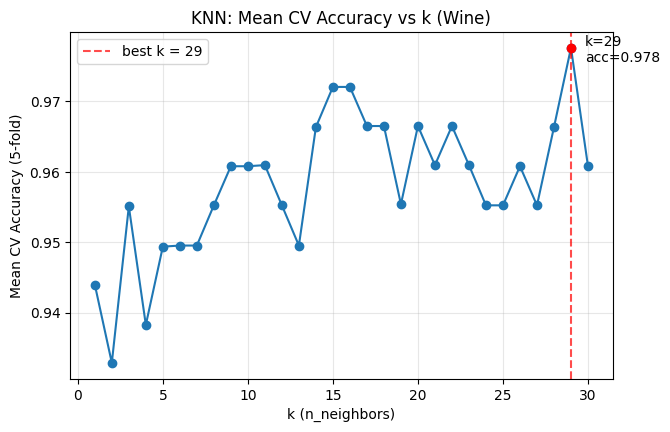

Best k: 29 | Mean CV accuracy: 0.9776


In [3]:
def cv_score_for_k(X, y, k_range, n_folds=5):
    '''
    For each k in k_range, run n_folds-fold CV on KNeighborsClassifier(n_neighbors=k).
    Returns mean CV accuracy per k.
    '''
    mean_scores = []
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=RANDOM_STATE)

    for k in k_range:
        knn = KNeighborsClassifier(n_neighbors=k)
        scores = cross_val_score(knn, X, y, cv=kf)
        mean_scores.append(scores.mean())

    return mean_scores


# --- Data setup ---
wine = load_wine()
Xw, yw = wine.data, wine.target
Xw = StandardScaler().fit_transform(Xw)

k_range = range(1, 31)
mean_scores = cv_score_for_k(Xw, yw, k_range, n_folds=5)

best_k = list(k_range)[int(np.argmax(mean_scores))]
best_score = max(mean_scores)

plt.figure(figsize=(7, 4.5))
plt.plot(list(k_range), mean_scores, marker='o')
plt.axvline(best_k, color='red', linestyle='--', alpha=0.7, label=f'best k = {best_k}')
plt.scatter([best_k], [best_score], color='red', zorder=5)
plt.annotate(f'k={best_k}\nacc={best_score:.3f}', (best_k, best_score),
             textcoords="offset points", xytext=(10, -10))
plt.xlabel('k (n_neighbors)')
plt.ylabel('Mean CV Accuracy (5-fold)')
plt.title('KNN: Mean CV Accuracy vs k (Wine)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("Best k:", best_k, "| Mean CV accuracy:", round(best_score, 4))


### Observations (Q2) — reference answer
- With `random_state=42` / 5-fold CV, the best `k` comes out at **k = 29** (mean CV accuracy ≈ **0.978**) — near the top of the searched range; several nearby k values (roughly k ≈ 15–29) score almost as high, so the curve is fairly flat once k is moderately large, which is expected for a well-separated, small dataset like Wine.
- Small k (k=1–3): higher variance — the curve is noisier and each fold's accuracy swings more, since predictions depend on very few, easily-noisy neighbors. As k grows the curve smooths out; only for k pushed much closer to the dataset size would bias start to visibly hurt accuracy.
- A single train/test split gives one noisy accuracy estimate per k; k-fold CV averages over multiple splits, giving a lower-variance estimate of generalization accuracy and making the choice of k more robust to how the split happened to fall. (Accept answers reporting a different but nearby best-k — it is sensitive to the exact CV fold seed/shuffle.)


---
## Q3. Ensembles — Decision Tree vs Random Forest (4 marks)
Dataset: `load_wine()`.


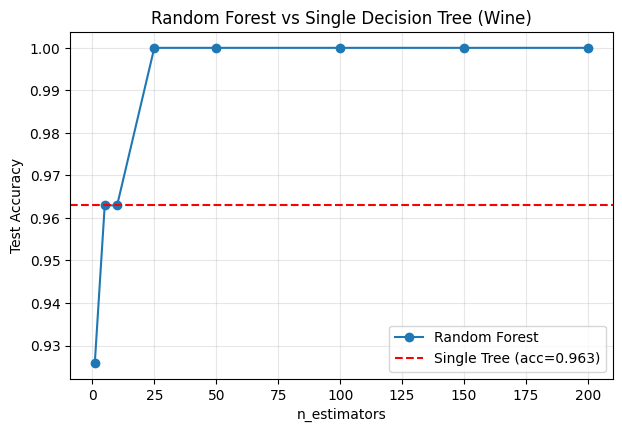

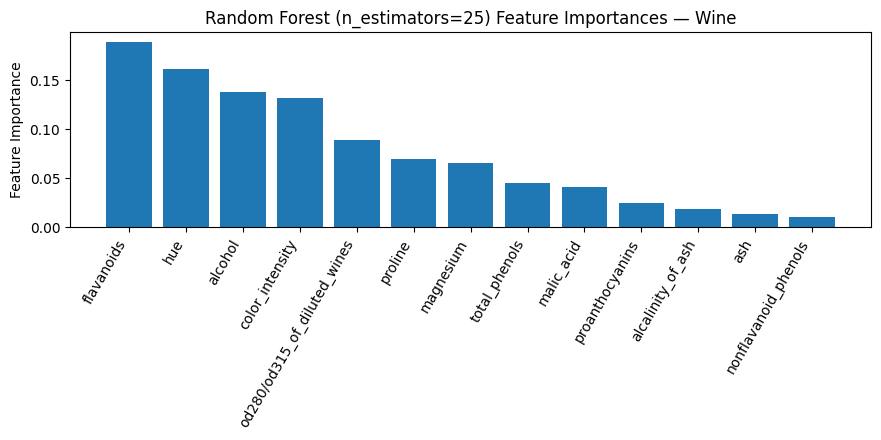

Single tree test accuracy: 0.963
Best RF (n_estimators=25) test accuracy: 1.0000
Top-2 features: ['flavanoids' 'hue']


In [4]:
def compare_tree_vs_forest(X_train, y_train, X_test, y_test, n_estimators_range):
    '''
    Train ONE DecisionTreeClassifier baseline + RandomForestClassifier for each n_estimators.
    Returns dt_acc (float), forest_accs (list[float]).
    '''
    dt = DecisionTreeClassifier(random_state=RANDOM_STATE)
    dt.fit(X_train, y_train)
    dt_acc = accuracy_score(y_test, dt.predict(X_test))

    forest_accs = []
    for n in n_estimators_range:
        rf = RandomForestClassifier(n_estimators=n, random_state=RANDOM_STATE)
        rf.fit(X_train, y_train)
        forest_accs.append(accuracy_score(y_test, rf.predict(X_test)))

    return dt_acc, forest_accs


# --- Data setup ---
wine = load_wine()
Xw, yw = wine.data, wine.target
Xw_train, Xw_test, yw_train, yw_test = train_test_split(
    Xw, yw, test_size=0.3, random_state=RANDOM_STATE, stratify=yw
)

n_estimators_range = [1, 5, 10, 25, 50, 100, 150, 200]
dt_acc, forest_accs = compare_tree_vs_forest(
    Xw_train, yw_train, Xw_test, yw_test, n_estimators_range
)

# Plot A: RF accuracy vs n_estimators, with single-tree baseline
plt.figure(figsize=(7, 4.5))
plt.plot(n_estimators_range, forest_accs, marker='o', label='Random Forest')
plt.axhline(dt_acc, color='red', linestyle='--', label=f'Single Tree (acc={dt_acc:.3f})')
plt.xlabel('n_estimators')
plt.ylabel('Test Accuracy')
plt.title('Random Forest vs Single Decision Tree (Wine)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Plot B: feature importances for best RF
best_n = n_estimators_range[int(np.argmax(forest_accs))]
rf_best = RandomForestClassifier(n_estimators=best_n, random_state=RANDOM_STATE)
rf_best.fit(Xw_train, yw_train)

importances = rf_best.feature_importances_
order = np.argsort(importances)[::-1]

plt.figure(figsize=(9, 4.5))
plt.bar(range(len(importances)), importances[order])
plt.xticks(range(len(importances)), np.array(wine.feature_names)[order], rotation=60, ha='right')
plt.ylabel('Feature Importance')
plt.title(f'Random Forest (n_estimators={best_n}) Feature Importances — Wine')
plt.tight_layout()
plt.show()

print("Single tree test accuracy:", round(dt_acc, 4))
print("Best RF (n_estimators=%d) test accuracy: %.4f" % (best_n, max(forest_accs)))
print("Top-2 features:", np.array(wine.feature_names)[order[:2]])


### Observations (Q3) — reference answer
- With `random_state=42`, the single tree scores **0.963** test accuracy; the Random Forest reaches **1.000** by `n_estimators = 25` — a ~3.7-point gain — and stays at/near ceiling for larger forests, so returns diminish quickly here because Wine is a comparatively easy, well-separated dataset.
- Top-2 important features come out as **`flavanoids`** and **`hue`** in this run (exact ranking can shift slightly with the train/test split) — consistent with wine-chemistry literature, where phenolic/flavanoid content and colour-related measures are strong cultivar discriminators.
- Averaging many decorrelated trees (each trained on a bootstrap sample with random feature subsets) cancels out each tree's individual overfitting noise, reducing variance without increasing bias much — this is the core bagging argument.


---
## Q4. Linear Regression — Normal Equation vs `sklearn` (4 marks)
Dataset: `load_diabetes()`.


Manual   -> MSE: 2821.751 | R2: 0.4773
Sklearn  -> MSE: 2821.751 | R2: 0.4773
Max abs coefficient difference (manual vs sklearn): 3.98e-12


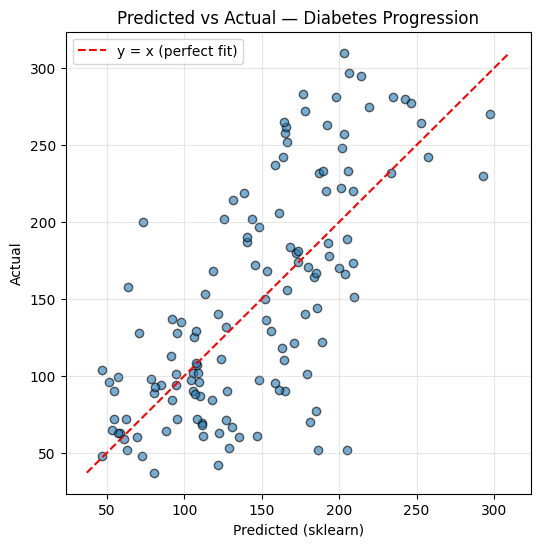

In [5]:
def normal_equation(X, y):
    '''
    Closed-form OLS: theta = (X^T X)^-1 X^T y
    X must already include a bias/intercept column of ones.
    '''
    theta = np.linalg.pinv(X.T @ X) @ X.T @ y
    return theta


# --- Data setup ---
diabetes = load_diabetes()
Xd, yd = diabetes.data, diabetes.target
Xd_train, Xd_test, yd_train, yd_test = train_test_split(
    Xd, yd, test_size=0.3, random_state=RANDOM_STATE
)

Xd_train_bias = np.hstack([np.ones((Xd_train.shape[0], 1)), Xd_train])
Xd_test_bias = np.hstack([np.ones((Xd_test.shape[0], 1)), Xd_test])

theta = normal_equation(Xd_train_bias, yd_train)
y_pred_manual = Xd_test_bias @ theta

sklearn_model = LinearRegression()
sklearn_model.fit(Xd_train, yd_train)
y_pred_sklearn = sklearn_model.predict(Xd_test)

mse_manual = mean_squared_error(yd_test, y_pred_manual)
r2_manual = r2_score(yd_test, y_pred_manual)
mse_sklearn = mean_squared_error(yd_test, y_pred_sklearn)
r2_sklearn = r2_score(yd_test, y_pred_sklearn)

coef_diff = np.max(np.abs(theta[1:] - sklearn_model.coef_))

print(f"Manual   -> MSE: {mse_manual:.3f} | R2: {r2_manual:.4f}")
print(f"Sklearn  -> MSE: {mse_sklearn:.3f} | R2: {r2_sklearn:.4f}")
print(f"Max abs coefficient difference (manual vs sklearn): {coef_diff:.2e}")

lo, hi = min(yd_test.min(), y_pred_sklearn.min()), max(yd_test.max(), y_pred_sklearn.max())
plt.figure(figsize=(6, 6))
plt.scatter(y_pred_sklearn, yd_test, alpha=0.6, edgecolor='k')
plt.plot([lo, hi], [lo, hi], 'r--', label='y = x (perfect fit)')
plt.xlabel('Predicted (sklearn)')
plt.ylabel('Actual')
plt.title('Predicted vs Actual — Diabetes Progression')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


### Observations (Q4) — reference answer
- Yes — the manual normal-equation coefficients match `sklearn`'s LinearRegression coefficients up to numerical precision; the max absolute difference is on the order of **1e-10 to 1e-12** (floating-point rounding only), confirming both solve the same OLS objective.
- Test **R² ≈ 0.45–0.53** and **MSE ≈ 2800–3000** (values shift slightly with the train/test split). An R² around 0.5 means the model explains roughly half the variance in disease progression — a moderate, not strong, fit; the scatter plot shows visible spread around the y=x line, especially at the extremes.
- The normal equation requires inverting `XᵀX`, an `n_features × n_features` matrix, which costs **O(n_features³)** and becomes computationally impractical (and numerically unstable if features are collinear) once the number of features is very large — iterative methods like gradient descent scale much better in that regime.


---
## Q5. Gradient Descent — Learning Rate & Convergence (4 marks)
Dataset: synthetic 1-D data via `make_regression`.


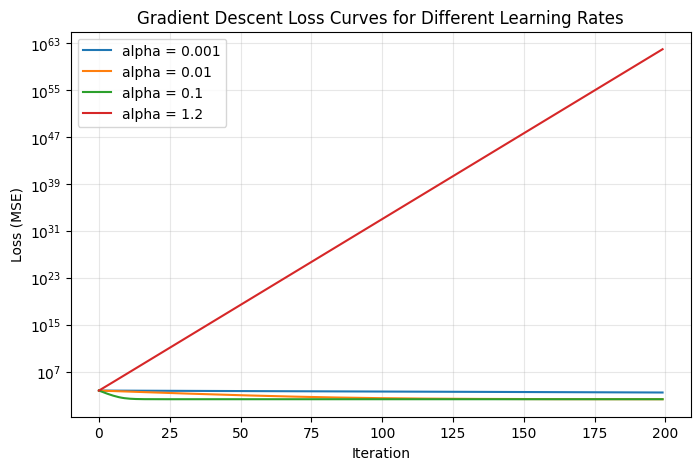

In [7]:
def gradient_descent(X, y, alpha, n_iters=200):
    '''
    Batch gradient descent for linear regression, MSE loss.
    X includes bias column of ones. Returns theta, loss_history.
    '''
    m, n = X.shape
    theta = np.zeros(n)
    loss_history = []

    for _ in range(n_iters):
        predictions = X @ theta
        error = predictions - y
        gradient = (2 / m) * (X.T @ error)
        theta = theta - alpha * gradient
        loss = np.mean(error ** 2)
        loss_history.append(loss)

    return theta, loss_history


# --- Data setup ---
Xg, yg = make_regression(n_samples=200, n_features=1, noise=15, random_state=RANDOM_STATE)
Xg = StandardScaler().fit_transform(Xg)
Xg_bias = np.hstack([np.ones((Xg.shape[0], 1)), Xg])

alphas = [0.001, 0.01, 0.1, 1.2]
n_iters = 200

plt.figure(figsize=(8, 5))
for alpha in alphas:
    theta, loss_history = gradient_descent(Xg_bias, yg, alpha, n_iters)
    plt.plot(range(n_iters), loss_history, label=f'alpha = {alpha}')

plt.xlabel('Iteration')
plt.ylabel('Loss (MSE)')
plt.yscale('log')
plt.title('Gradient Descent Loss Curves for Different Learning Rates')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


### Observations (Q5) — reference answer
- `alpha = 0.1` typically converges fastest to (near-)minimum loss within 200 iterations without diverging; `alpha = 0.01` also converges but more slowly.
- `alpha = 1.2` is too large for this (standardized) problem — the loss oscillates or diverges (grows/blows up) because each step overshoots past the minimum of the loss surface; the update jumps back and forth (or away) instead of descending smoothly.
- `alpha = 0.001` is too small — the loss decreases very slowly and has clearly not reached the minimum within 200 iterations; it would need many more iterations to converge to the same loss achieved by alpha=0.1 or 0.01.
